# Volcanicus tutorial

`volcanicus` wraps per-volcano deformation/residual measurements — one row per date/direction, one column per distance bin — in a `Volcano` object, taking care of dtype normalization and offering quick summary, statistics and plotting helpers on top of the pandas stack.

This notebook walks through:

1. Loading a bundled dataset
2. Inspecting the normalized `DataFrame`
3. Summarizing measurements with `Volcano.radial_profile()`
4. Plotting with the `.plots` accessor
5. Computing statistics with the `.stats` accessor


In [1]:
import volcanicus

volcanicus.__all__

['Volcano',
 'normalize_dataframe',
 'read_csv',
 'PlotAccessor',
 'StatsAccessor',
 'datasets']

## 1. Loading a bundled dataset

`volcanicus.datasets` ships a few example datasets, loadable by name.

In [2]:
volcanicus.datasets.available()

['copahue', 'etna']

In [3]:
etna = volcanicus.datasets.load("etna")
etna

dates,99
missing,4315
registers,790


You can also build a `Volcano` from your own CSV file, either with the classmethod or the module-level shortcut:

```python
volcano = volcanicus.Volcano.from_csv("measurements.csv", volcano_name="Copahue")
volcano = volcanicus.read_csv("measurements.csv", volcano_name="Copahue")
```

The CSV is expected to have a `date` column, `center_lat`/`center_long`, a `direction` column, and one column per distance bin (everything else).

## 2. Inspecting the normalized `DataFrame`

`Volcano.__init__` normalizes dtypes on the way in: `date` is parsed as `datetime`, `center_lat`/`center_long` and the distance-bin columns as numeric, and `direction` as a category. `.dataframe` always returns a copy, so the internal state can't be mutated from the outside.

In [4]:
etna.dataframe.head()

,date,center_lat,center_long,direction,15m,45m,75m,105m,135m,165m,...,615m,645m,675m,705m,735m,765m,795m,825m,855m,885m
0,2000-07-26,37.7464,15.0073,E,0.5395,0.3623,0.2461,0.1103,0.0178,0.0227,...,-0.0776,-0.0789,-0.0773,-0.0733,-0.0540,-0.0543,-0.0657,-0.0684,-0.0702,-0.0641
1,2000-07-26,37.7464,15.0073,N,0.3843,0.3879,0.2208,0.1241,0.0467,0.0497,...,-0.0723,-0.0681,-0.0634,-0.0360,-0.0302,-0.0392,-0.0149,0.0151,0.0206,0.0365
2,2000-07-26,37.7464,15.0073,NE,0.4063,0.4107,0.2132,0.0754,0.0157,-0.0163,...,0.0058,0.0070,-0.0138,0.0065,0.0084,-0.0098,-0.0328,-0.0284,-0.0433,-0.0394
3,2000-07-26,37.7464,15.0073,NO,NaN,0.2892,0.2235,0.1337,0.0978,0.0633,...,-0.0234,-0.0285,-0.0219,-0.0090,-0.0085,-0.0059,-0.0014,0.0028,0.0085,0.0322
4,2000-07-26,37.7464,15.0073,O,NaN,0.4206,0.3449,0.2232,0.1313,0.0506,...,-0.0110,-0.0126,0.0030,0.0102,0.0221,0.0279,0.0098,-0.0073,-0.0317,-0.0533


In [5]:
etna.dataframe.dtypes.head()

date           datetime64[ns]
center_lat            float64
center_long           float64
direction            category
15m                   float64
dtype: object

## 3. Summarizing measurements

`radial_profile()` averages the measurements over dates, per direction, producing one row per direction with the mean of every distance bin — the spatial curve, residual vs. distance.

`temporal_profile()` is its mirror: it averages over distance bins instead, producing one row per date with one column per direction — the temporal curve, residual vs. date.

In [6]:
etna.radial_profile()

,15m,45m,75m,105m,135m,165m,195m,225m,255m,285m,...,615m,645m,675m,705m,735m,765m,795m,825m,855m,885m
direction,,,,,,,,,,,,,,,,,,,,,
E,0.371373,0.272800,0.189716,0.142984,0.116166,0.094440,0.090814,0.065835,0.039673,0.019007,...,-0.006564,-0.006632,-0.004757,-0.002809,-0.001886,0.000347,0.000347,-0.003526,-0.003771,-0.003585
N,0.247392,0.196262,0.127873,0.093690,0.058153,0.042932,0.044447,0.030094,0.025957,0.018542,...,-0.011301,-0.008429,-0.007031,-0.009669,-0.008765,-0.006954,-0.006656,-0.005237,-0.004688,-0.001959
NE,0.300232,0.277657,0.195775,0.142963,0.111649,0.089847,0.066271,0.052470,0.043535,0.045834,...,-0.001980,-0.003060,-0.008615,-0.010006,-0.019107,-0.019884,-0.023556,-0.024533,-0.029736,-0.032178
NO,0.275927,0.219451,0.171200,0.105266,0.094334,0.088870,0.070229,0.063801,0.058315,0.049337,...,-0.009071,-0.014854,-0.013876,-0.012810,-0.009161,-0.007158,-0.009572,-0.010081,-0.004367,-0.003055
O,0.356040,0.308743,0.204983,0.138558,0.120303,0.096544,0.080024,0.067265,0.061105,0.050575,...,-0.002653,-0.010174,-0.013594,-0.013626,-0.016569,-0.017501,-0.016448,-0.015188,-0.014571,-0.008550
S,0.289061,0.284103,0.210740,0.165876,0.126052,0.100131,0.084126,0.066032,0.049093,0.031572,...,0.001060,0.004042,0.003824,0.005256,-0.003039,-0.007186,-0.013956,-0.016651,-0.017434,-0.021760
SE,0.317587,0.293560,0.219379,0.180023,0.152292,0.123560,0.097107,0.056354,0.043777,0.042773,...,-0.001631,-0.004081,-0.004162,-0.007733,-0.010716,-0.009258,-0.019307,-0.020170,-0.027307,-0.026811
SO,0.411945,0.296544,0.232454,0.164477,0.131767,0.103760,0.095009,0.070436,0.059051,0.045209,...,-0.020795,-0.016705,-0.018752,-0.017140,-0.010895,-0.010893,-0.012448,-0.019061,-0.023143,-0.018603


In [7]:
etna.temporal_profile().iloc[:5, :6]

direction,E,N,NE,NO,O,S
date,,,,,,
2000-07-26,0.056967,0.029077,0.045677,0.029207,0.048990,0.044527
2001-06-27,0.107037,0.004512,0.063200,0.055097,0.032279,0.059103
2001-07-13,0.049444,0.033950,0.179943,0.108969,0.096848,0.013970
2001-07-29,0.053738,0.053427,0.082808,0.050145,0.059545,0.782550
2001-08-30,0.055833,0.022893,0.059041,0.065020,0.000755,0.065410


## 4. Plotting with `.plots`

The `.plots` accessor follows the same pattern used across the library (`AccessorABC`): it's callable, dispatching to the method named `kind` (`"radial_profile"` by default), and its methods can also be called directly.

<Axes: title={'center': 'etna: residual vs. distance by direction'}, xlabel='Distance (m)', ylabel='Residual'>

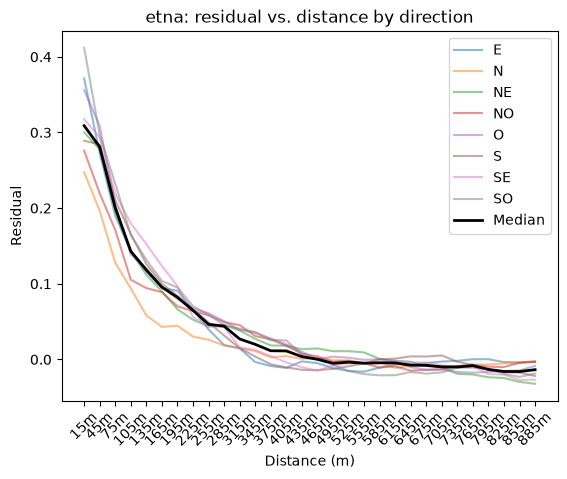

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

etna.plots.radial_profile()

The per-direction lines show `std` error bars when `std=True`, and the aggregate median line can be turned off with `mean=False`:

<Axes: title={'center': 'etna: residual vs. distance by direction'}, xlabel='Distance (m)', ylabel='Residual'>

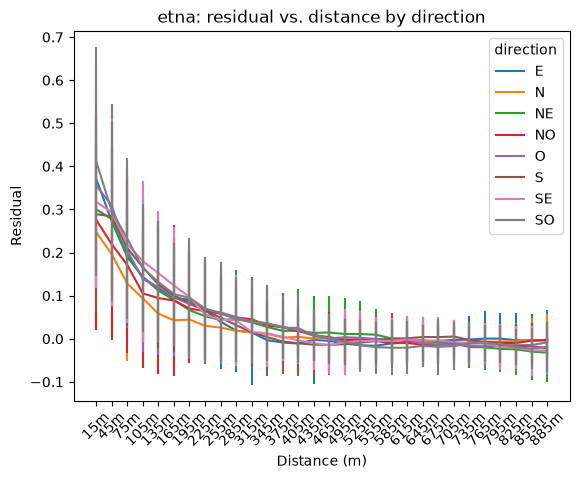

In [9]:
plt.figure()
etna.plots.radial_profile(std=True, mean=False)

Since `PlotAccessor` is callable, the same plot can be produced with the default kind:

```python
etna.plots()  # same as etna.plots.radial_profile()
etna.plots("radial_profile", mean=False)
```


`temporal_profile()` is the plot's temporal mirror: same two-layer plot (one line per direction, plus an aggregate median line), but with `date` on the x-axis. Error bars on the per-direction lines come from the spread across distance bins at each date, instead of across dates at each distance bin.

<Axes: title={'center': 'etna: residual vs. date by direction'}, xlabel='Date', ylabel='Residual'>

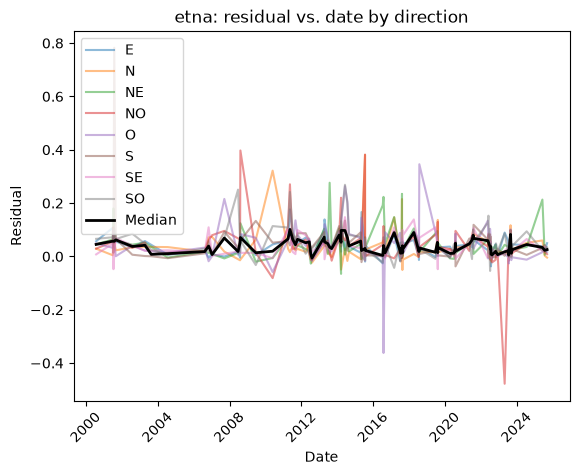

In [10]:
plt.figure()
etna.plots.temporal_profile()

## 5. Statistics with `.stats`

The `.stats` accessor exposes a whitelist of pandas statistical methods (`describe`, `mean`, `median`, `std`, `var`, `cov`, `kurtosis`, `sem`, `skew`, `min`, `max`, `quantile`, `pct_change`). Every one of them takes a mandatory first parameter, `groupby`, which can only be `"date"` or `"direction"` — the measurements are grouped by that column before the statistic is computed.

In [11]:
etna.stats.mean(groupby="direction").iloc[:, :6]

,15m,45m,75m,105m,135m,165m
direction,,,,,,
E,0.371373,0.272800,0.189716,0.142984,0.116166,0.094440
N,0.247392,0.196262,0.127873,0.093690,0.058153,0.042932
NE,0.300232,0.277657,0.195775,0.142963,0.111649,0.089847
NO,0.275927,0.219451,0.171200,0.105266,0.094334,0.088870
O,0.356040,0.308743,0.204983,0.138558,0.120303,0.096544
S,0.289061,0.284103,0.210740,0.165876,0.126052,0.100131
SE,0.317587,0.293560,0.219379,0.180023,0.152292,0.123560
SO,0.411945,0.296544,0.232454,0.164477,0.131767,0.103760


In [12]:
etna.stats.describe(groupby="direction").iloc[:, :3]

15m        45m        75m
direction                                       
E         count  60.000000  78.000000  74.000000
          mean    0.371373   0.272800   0.189716
          std     0.211283   0.169257   0.155733
          min    -0.001800   0.006600  -0.106400
          25%     0.213200   0.150800   0.087950
...                    ...        ...        ...
SO        min    -0.053100  -0.084300  -0.114600
          25%     0.176400   0.133100   0.108300
          50%     0.440300   0.268800   0.215700
          75%     0.552800   0.410150   0.351400
          max     1.123200   1.094300   1.046800

[64 rows x 3 columns]

`.stats` is also callable, dispatching to `_default_kind` (`"describe"`) when no kind is given:

In [13]:
etna.stats(groupby="date").iloc[:, :3]

15m       45m       75m
date                                          
2000-07-26 count  5.000000  8.000000  8.000000
           mean   0.431300  0.342187  0.229075
           std    0.102094  0.081838  0.069947
           min    0.298100  0.197800  0.115800
           25%    0.384300  0.283050  0.203325
...                    ...       ...       ...
2025-09-08 min    0.061000  0.030700  0.029800
           25%    0.071275  0.090575  0.076925
           50%    0.091900  0.108800  0.100250
           75%    0.141850  0.167675  0.148700
           max    0.240100  0.215900  0.200300

[792 rows x 3 columns]

Passing anything other than `"date"` or `"direction"` raises a clear error:

In [14]:
try:
    etna.stats.mean(groupby="center_lat")
except ValueError as e:
    print("ValueError:", e)

ValueError: 'groupby' must be one of ('date', 'direction'), found 'center_lat'


## 6. Missing values

Real deformation datasets have gaps. `has_missing` is a quick check, and `missing_report()` summarizes how missing values are distributed across dates.

In [15]:
etna.has_missing

True

In [16]:
etna.missing_report()

n_missing                               4315
n_dates                                   99
n_dates_with_missing                      99
missing_per_date_min                       3
missing_per_date_max                     481
missing_per_date_mean              43.585859
worst_date               2023-08-18 00:00:00
dtype: object

## 7. Imputing missing values

`impute()` fills the gaps in two steps: it linearly interpolates each date/direction row along its distance bins (interior gaps only), and for any row still fully missing after that, it averages the same date's two compass-adjacent directions.

In [17]:
imputed = etna.impute()

display(etna, imputed)

dates,99
missing,4315
registers,790


dates,99
missing,2338
registers,790


Comparing the radial and temporal profiles before/after makes the effect of imputation easy to see — the shape stays the same, gaps in the lines get filled in:

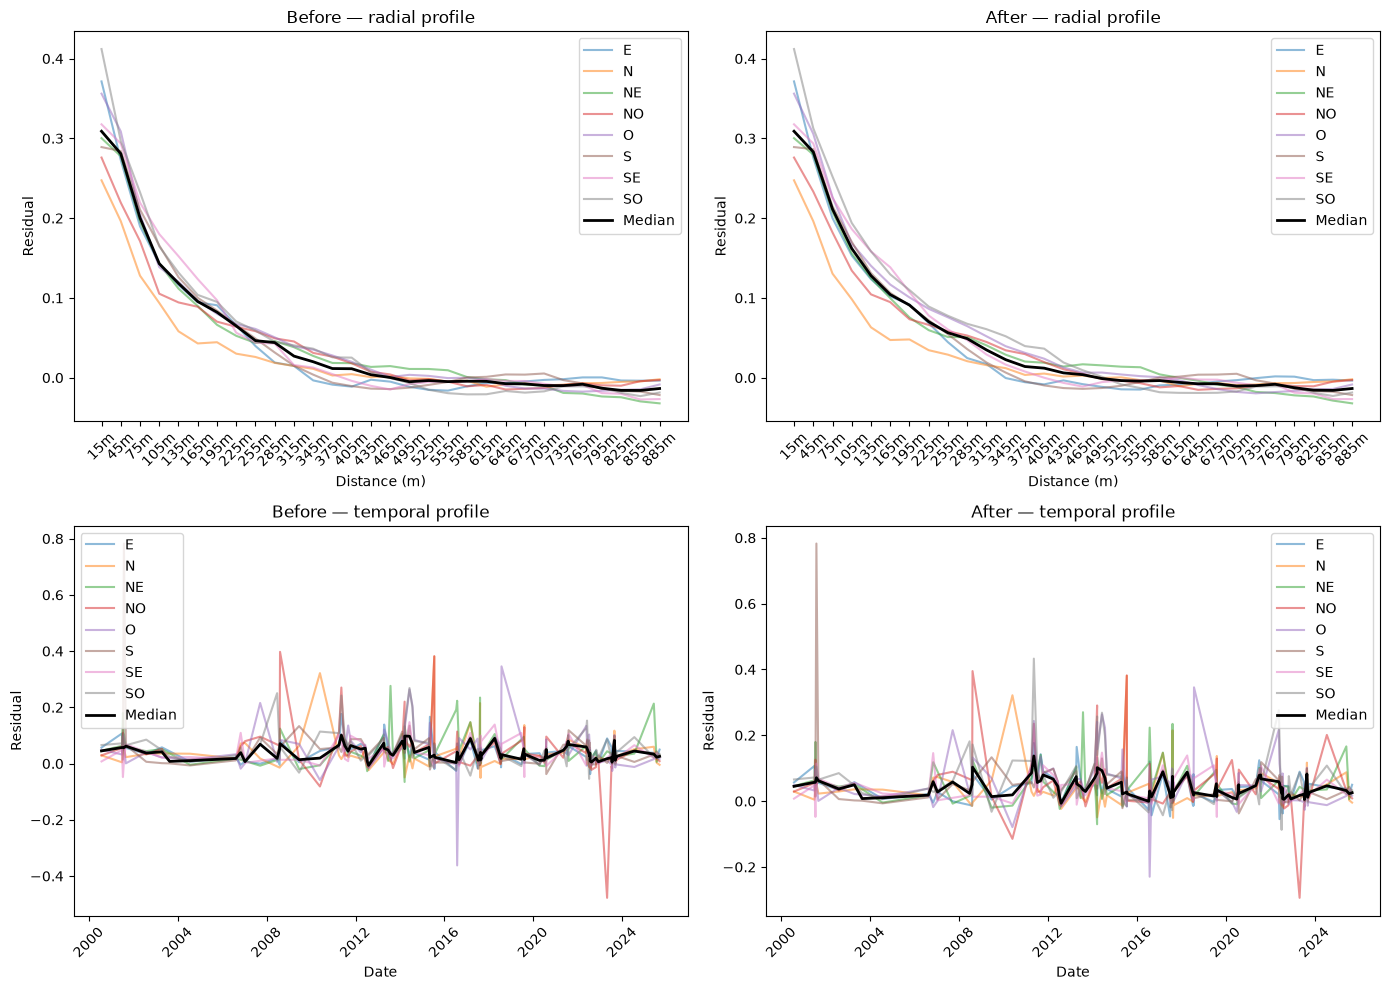

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

etna.plots.radial_profile(ax=axes[0, 0])
axes[0, 0].set_title("Before — radial profile")

imputed.plots.radial_profile(ax=axes[0, 1])
axes[0, 1].set_title("After — radial profile")

etna.plots.temporal_profile(ax=axes[1, 0])
axes[1, 0].set_title("Before — temporal profile")

imputed.plots.temporal_profile(ax=axes[1, 1])
axes[1, 1].set_title("After — temporal profile")

fig.tight_layout()

## Next steps

- [README.md](../README.md) for installation and a quick reference.
- `volcanicus.datasets.available()` for the full list of bundled datasets.
- `volcanicus.utils.AccessorABC` if you want to add your own accessor following the same `volcano.<accessor>(kind, **kwargs)` pattern used by `.plots` and `.stats`.
